# PCA with the Palmer Penguins Dataset

The Palmer Penguins dataset contains measurements of three penguin species — *Adelie*, *Chinstrap*, and *Gentoo* — collected from three islands in the Palmer Archipelago, Antarctica.

We have **four numeric features**:
- `bill_length_mm`
- `bill_depth_mm`
- `flipper_length_mm`
- `body_mass_g`

These features are correlated. PCA will find new axes (principal components) that capture the maximum variance and are uncorrelated with each other.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 1. Load & Explore the Data

In [2]:
penguins = sns.load_dataset('penguins').dropna()

print(f"Shape: {penguins.shape}")
print(f"Species counts:\n{penguins['species'].value_counts()}")
penguins.head()

Shape: (333, 7)
Species counts:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


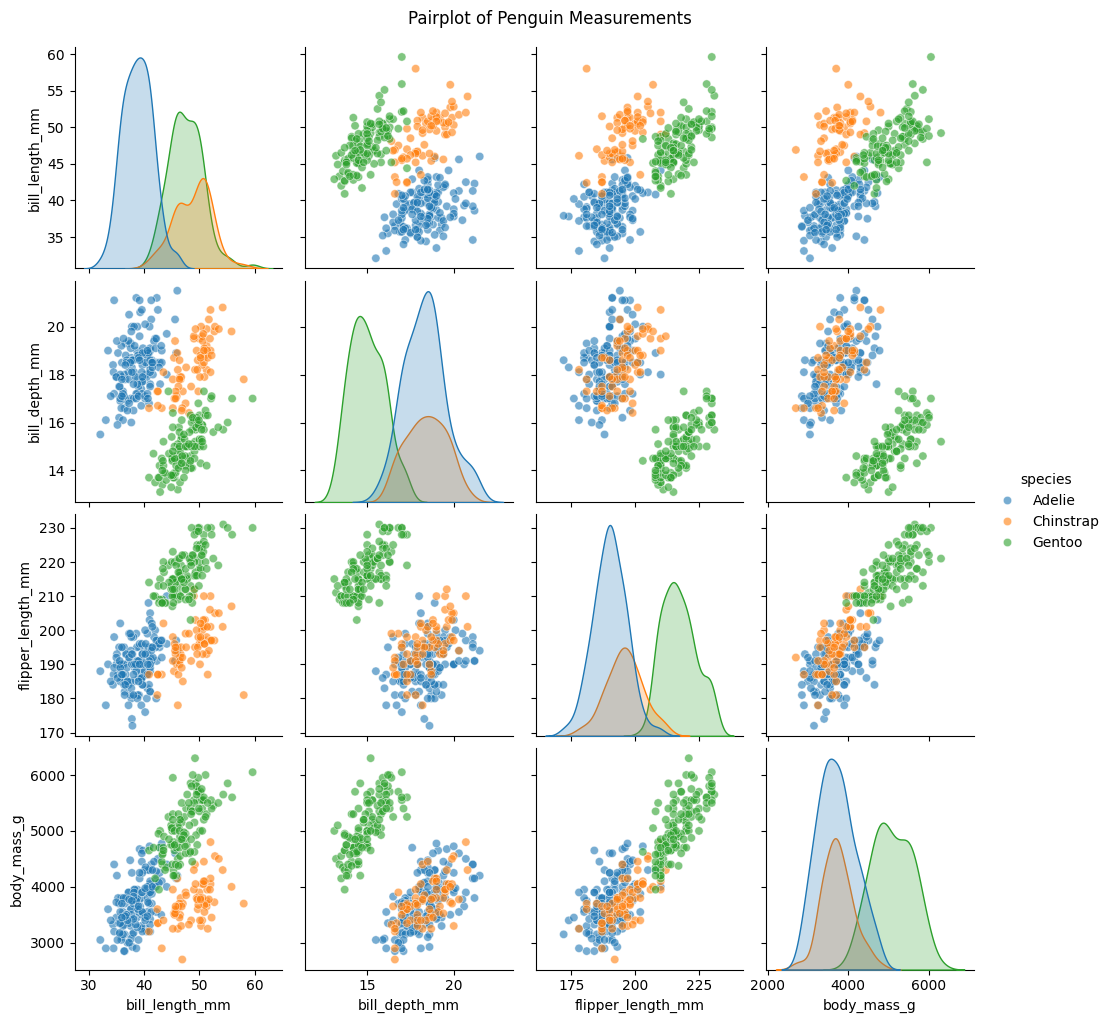

In [3]:
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

sns.pairplot(penguins, vars=numeric_features, hue='species', palette='tab10', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Penguin Measurements', y=1.02)
plt.show()

Notice the correlations between features — for example, `flipper_length_mm` and `body_mass_g` are strongly positively correlated. PCA will combine correlated features into single components.

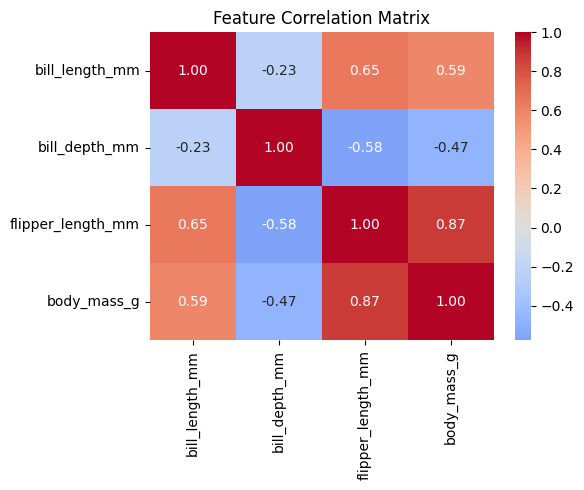

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = penguins[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 2. Preprocessing: Scale the Features

PCA is sensitive to scale — features with larger ranges will dominate the components. We **must** standardize before applying PCA.

In [5]:
X = penguins[numeric_features]
y = penguins['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)
Xs_all   = scaler.transform(X)   # for visualization

## 3. Fit PCA & Explained Variance

We first fit PCA with all 4 components to see how much variance each one captures.

In [6]:
pca_full = PCA(n_components=4)
pca_full.fit(Xs_train)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance per component:")
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {ev:.3f}  (cumulative: {cum:.3f})")

Explained variance per component:
  PC1: 0.701  (cumulative: 0.701)
  PC2: 0.188  (cumulative: 0.888)
  PC3: 0.085  (cumulative: 0.974)
  PC4: 0.026  (cumulative: 1.000)


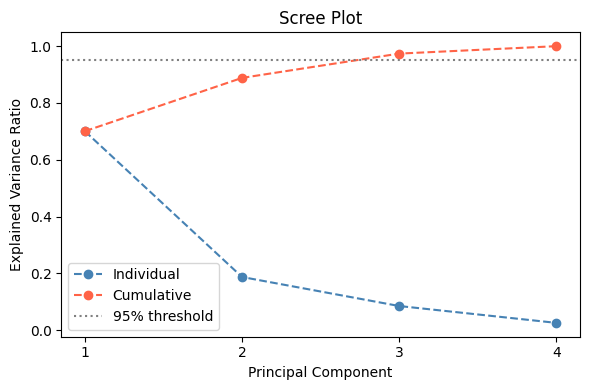

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(range(1, 5), explained, 'o--', color='steelblue', label='Individual')
ax.plot(range(1, 5), cumulative, 'o--', color='tomato', label='Cumulative')
ax.axhline(0.95, color='gray', linestyle=':', label='95% threshold')

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot')
ax.set_xticks(range(1, 5))
ax.legend()
plt.tight_layout()
plt.show()

The first two components together explain ~88% of the total variance. The first component alone captures ~69%. This means we can represent 4D data in 2D while retaining most of the information.

## 4. Interpreting the Components: Loadings

The **loadings** tell us how much each original feature contributes to each principal component.

In [8]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=numeric_features,
    columns=[f'PC{i+1}' for i in range(4)]
)
loadings

,PC1,PC2,PC3,PC4
bill_length_mm,0.457046,0.604283,0.635570,-0.148332
bill_depth_mm,-0.406893,0.792941,-0.423332,0.162706
flipper_length_mm,0.571833,0.006990,-0.234383,0.786144
body_mass_g,0.546401,0.077709,-0.601586,-0.577496


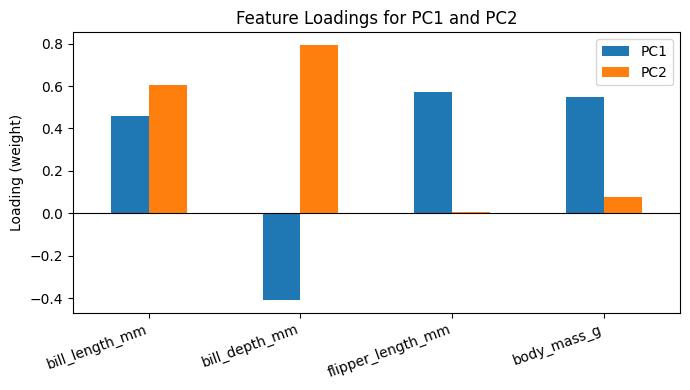

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
loadings[['PC1', 'PC2']].plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticklabels(numeric_features, rotation=20, ha='right')
ax.set_ylabel('Loading (weight)')
ax.set_title('Feature Loadings for PC1 and PC2')
ax.legend()
plt.tight_layout()
plt.show()

**Interpreting PC1:** Flipper length and body mass increase together, bills get longer but less deep. This component captures **overall body size**: longer flippers, heavier body mass, longer bill.

**Interpreting PC2:** Bill depth loads strongly *negatively* while bill length loads *positively*. PC2 captures **bill shape** — separating deep-billed vs. long-billed penguins.

## 5. Visualize the 2D PCA Projection

In [10]:
pca2 = PCA(n_components=2)
P_train = pca2.fit_transform(Xs_train)
P_test  = pca2.transform(Xs_test)
P_all   = pca2.transform(Xs_all)

# Build a DataFrame for easy plotting
pca_df = pd.DataFrame(P_all, columns=['PC1', 'PC2'])
pca_df['species'] = y.values
pca_df.head()

,PC1,PC2,species
0,-1.820711,0.074186,Adelie
1,-1.283693,-0.406735,Adelie
2,-1.351725,-0.121272,Adelie
3,-1.869044,0.034666,Adelie
4,-1.913053,0.868239,Adelie


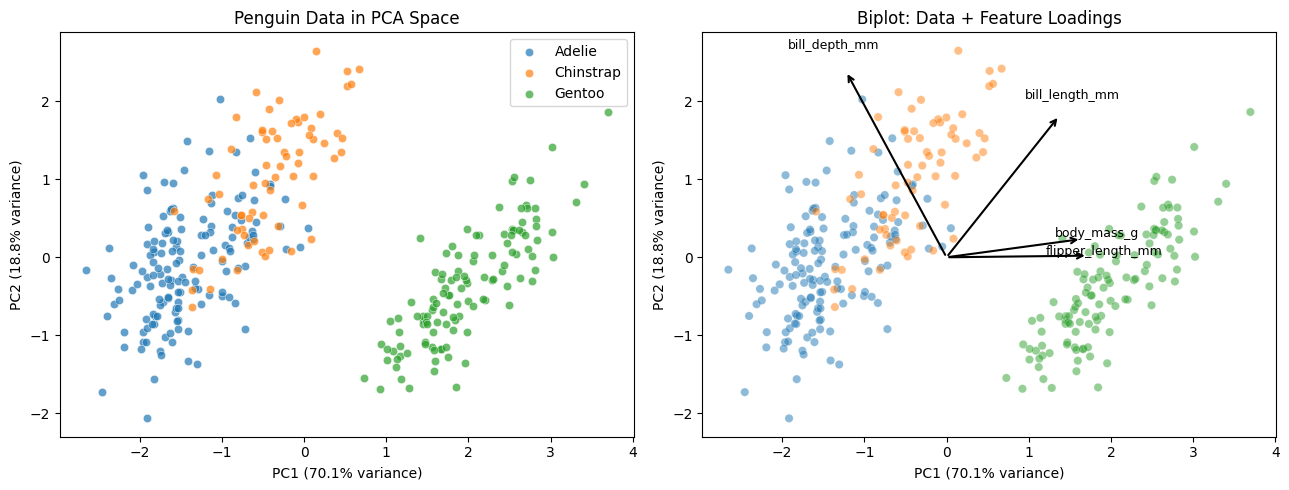

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: PCA scatter ---
palette = {'Adelie': 'tab:blue', 'Chinstrap': 'tab:orange', 'Gentoo': 'tab:green'}
for species, grp in pca_df.groupby('species'):
    axes[0].scatter(grp['PC1'], grp['PC2'], label=species, alpha=0.7,
                    color=palette[species], edgecolors='white', linewidths=0.4)

axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('Penguin Data in PCA Space')
axes[0].legend()

# --- Right: loading biplot arrows overlaid ---
axes[1].scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['species'].map(palette).values,
                alpha=0.5, edgecolors='white', linewidths=0.3)

scale = 3  # scale arrows to be visible relative to data
for feature, (lx, ly) in zip(numeric_features, pca2.components_.T):
    axes[1].annotate('', xy=(lx * scale, ly * scale), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    axes[1].text(lx * scale * 1.12, ly * scale * 1.12, feature,
                 ha='center', fontsize=9, color='black')

axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('Biplot: Data + Feature Loadings')

plt.tight_layout()
plt.show()

The scatter plot shows clean separation between species — especially Gentoo (right, large body size) and Adelie vs. Chinstrap (separated vertically by bill shape). 

The biplot arrows point in the direction each feature "pulls" — features that point in similar directions are correlated.

## 6. PCA for Dimensionality Reduction: Classification Pipeline

Now we compare a logistic regression classifier trained on **raw features** vs. **2 PCA components**.

In [12]:
# Pipeline 1: StandardScaler → LogisticRegression (all 4 features)
pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline 2: StandardScaler → PCA(2) → LogisticRegression
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_full.fit(X_train, y_train)
pipe_pca.fit(X_train, y_train)

acc_full = accuracy_score(y_test, pipe_full.predict(X_test))
acc_pca  = accuracy_score(y_test, pipe_pca.predict(X_test))

print(f"Accuracy with all 4 features:  {acc_full:.3f}")
print(f"Accuracy with 2 PCA components: {acc_pca:.3f}")
print(f"\nDimensionality reduced from 4 → 2 features ({(1 - 2/4)*100:.0f}% reduction)")
print(f"Variance retained: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

Accuracy with all 4 features:  1.000
Accuracy with 2 PCA components: 0.836

Dimensionality reduced from 4 → 2 features (50% reduction)
Variance retained: 88.8%


## 7. Choosing the Number of Components

How many components do we really need? Use cumulative explained variance and pick a threshold (e.g., 95%).

In [13]:
threshold = 0.95
n_components_needed = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= threshold) + 1
print(f"Components needed to explain ≥ {threshold*100:.0f}% variance: {n_components_needed}")

# Alternatively, let sklearn choose automatically
pca_auto = PCA(n_components=0.95)
pca_auto.fit(Xs_train)
print(f"sklearn auto-selected {pca_auto.n_components_} components for 95% variance")

Components needed to explain ≥ 95% variance: 3
sklearn auto-selected 3 components for 95% variance


## Summary

| Step | Key Takeaway |
|------|-------------|
| **Scale first** | PCA is sensitive to feature scale — always `StandardScaler` before PCA |
| **Scree plot** | Look for the "elbow" or use a variance threshold (e.g., 95%) to pick `n_components` |
| **Loadings** | Tell you which original features drive each component — helps interpretability |
| **Biplot** | Visualizes both data points and feature directions in PCA space |
| **Pipeline** | Wrap `StandardScaler → PCA → model` in a `Pipeline` so test data is transformed correctly |

**When to use PCA:**
- Many correlated features (consolidate them)
- Need 2D/3D visualization of high-dimensional data
- Want to reduce model complexity or training time
- Data has noise you want to suppress (noise tends to land in later components)